In [3]:
import numpy as np
from transformers import VideoLlavaProcessor, VideoLlavaForConditionalGeneration
import os
from PIL import Image
from datetime import datetime
import matplotlib.pyplot as plt
import torch

/home/gridsan/manderson/.conda/envs/skyscraper/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def extract_datetime(filename):
    # example: 40.1398_-120.9509_20210708_190325.jpg
    parts = filename.split("_")
    date_str = parts[2]   # 20210708
    time_str = parts[3].split(".")[0]  # 190325
    return datetime.strptime(date_str + time_str, "%Y%m%d%H%M%S")


def load_frames_from_folder(folder_path, num_frames=8):
    image_files = [
        f for f in os.listdir(folder_path)
        if f.endswith(".jpg") or f.endswith(".png")
    ]

    # sort by actual timestamp
    image_files = sorted(image_files, key=extract_datetime)

    image_paths = [os.path.join(folder_path, f) for f in image_files]

    if len(image_paths) == 0:
        raise ValueError("No images found")

    # sample or pad to 8 frames
    if len(image_paths) > num_frames:
        indices = np.linspace(0, len(image_paths) - 1, num_frames).astype(int)
        image_paths = [image_paths[i] for i in indices]
    elif len(image_paths) < num_frames:
        image_paths = image_paths + [image_paths[-1]] * (num_frames - len(image_paths))

    frames = []
    for p in image_paths:
        img = Image.open(p).convert("RGB")
        frames.append(np.array(img))

    return np.stack(frames)

def plot_frames_1x8(frames):
    fig, axes = plt.subplots(1, frames.shape[0], figsize=(20, 3))

    for i in range(frames.shape[0]):
        axes[i].imshow(frames[i])
        axes[i].axis("off")
        axes[i].set_title(f"{i}", fontsize=8)

    plt.tight_layout()
    plt.show()

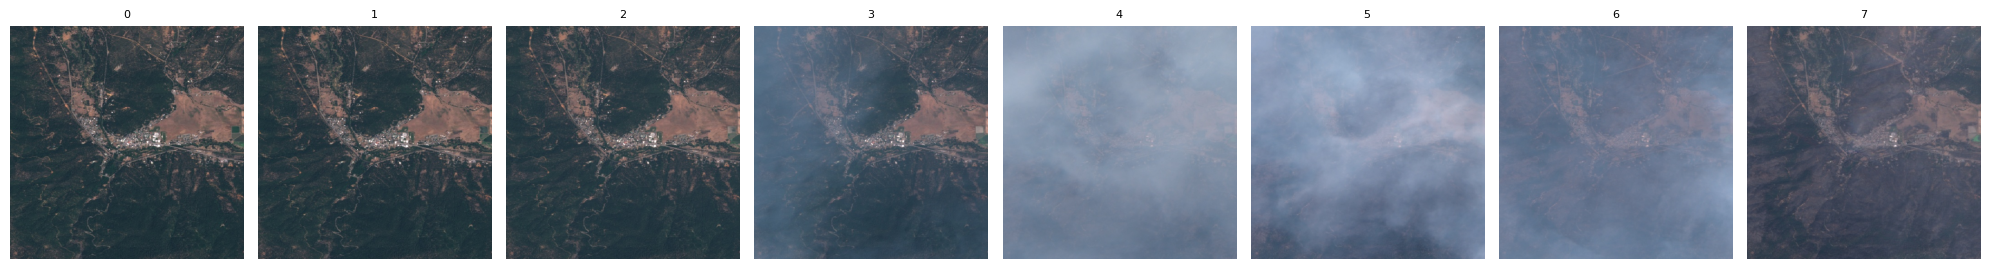

In [5]:
imagery_path = "/home/gridsan/manderson/skyscraper-s2/data/skyscraper_gdelt_sentinel/imagery/1021434538"
frames = load_frames_from_folder(imagery_path)
plot_frames_1x8(frames)

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = VideoLlavaForConditionalGeneration.from_pretrained(
    "/home/gridsan/manderson/.cache/huggingface/hub/models--LanguageBind--Video-LLaVA-7B-hf/snapshots/4cf9d8cfc76a54f46a4cb43be5368b46b7f0d736",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,)
processor = VideoLlavaProcessor.from_pretrained(
    "/home/gridsan/manderson/.cache/huggingface/hub/models--LanguageBind--Video-LLaVA-7B-hf/snapshots/4cf9d8cfc76a54f46a4cb43be5368b46b7f0d736")

prompt = "USER: <video>\nWhat is happening? ASSISTANT:"

inputs = processor(text=prompt, videos=frames, return_tensors="pt")

Loading weights: 100%|██████████| 1077/1077 [02:18<00:00,  7.75it/s, Materializing param=model.video_tower.vision_model.pre_layrnorm.weight]                        
The image processor of type `VideoLlavaImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


In [10]:
model.to(device)

# move to device if needed
inputs = {k: v.to(model.device) for k, v in inputs.items()}

# generate output tokens
output_ids = model.generate(
    **inputs,
    max_new_tokens=100
)

# decode to text
response = processor.batch_decode(output_ids, skip_special_tokens=True)[0]

print(response)

USER: 
What is happening? ASSISTANT: The image shows a large city with a lot of buildings and a lot of smoke coming out of them. The smoke is spreading across the city, creating a hazy atmosphere.


### Fix description json

In [12]:
# import json

# input_json = '/home/gridsan/manderson/skyscraper-s2/data/skyscraper_gdelt_sentinel/vqa/teochat_sentinel_event_description_train.json'
# output_json = '/home/gridsan/manderson/skyscraper-s2/data/skyscraper_gdelt_sentinel/vqa/teochat_sentinel_event_description_train.json'

# with open(input_json, "r") as f:
#     data = json.load(f)

# old_text = "Describe what event is occurring in these images in 2-3 sentences."
# new_text = "Describe what is occurring in these images in 2-3 sentences."

# count = 0

# for example in data:
#     for turn in example.get("conversations", []):
#         if turn.get("from") == "human" and old_text in turn.get("value", ""):
#             turn["value"] = turn["value"].replace(old_text, new_text)
#             count += 1

# print(f"Updated {count} prompts")

# with open(output_json, "w") as f:
#     json.dump(data, f, indent=2)

# print("Saved to", output_json)

Updated 2051 prompts
Saved to /home/gridsan/manderson/skyscraper-s2/data/skyscraper_gdelt_sentinel/vqa/teochat_sentinel_event_description_train.json
